In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/mohitrohda/Library/Python/3.10/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/mohitrohda/Library/Python/3.10/lib/python/site-packages/traitlets/c

## Dataset Paths
The dataset is organized into images and masks with train and validation splits.

In [6]:
IMAGE_TRAIN_DIR = "../data/oil_spill_dataset/images/train"
MASK_TRAIN_DIR  = "../data/oil_spill_dataset/masks/train"

IMAGE_VAL_DIR = "../data/oil_spill_dataset/images/val"
MASK_VAL_DIR  = "../data/oil_spill_dataset/masks/val"

## Exploratory Data Analysis (EDA)

In [7]:
def count_png_files(folder):
    return len([f for f in os.listdir(folder) if f.endswith(".png")])

print("Training Images:", count_png_files(IMAGE_TRAIN_DIR))
print("Training Masks:", count_png_files(MASK_TRAIN_DIR))
print("Validation Images:", count_png_files(IMAGE_VAL_DIR))
print("Validation Masks:", count_png_files(MASK_VAL_DIR))


Training Images: 6455
Training Masks: 6455
Validation Images: 1615
Validation Masks: 1615


## Sample Image and Mask Visualization

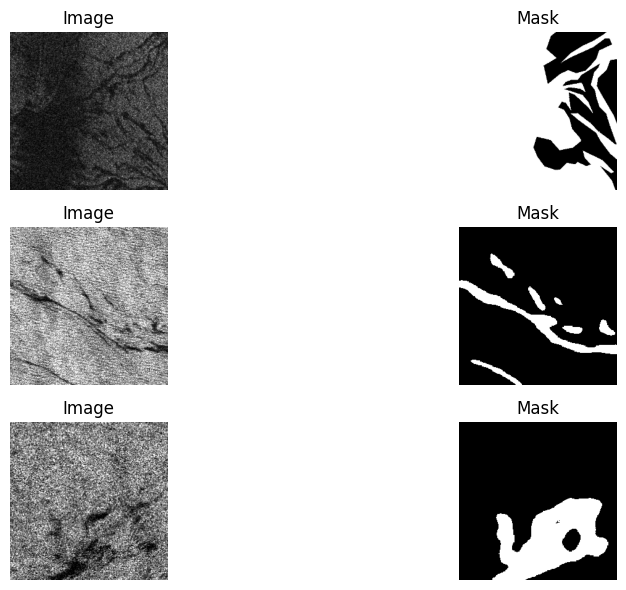

In [8]:
sample_images = os.listdir(IMAGE_TRAIN_DIR)[:3]

plt.figure(figsize=(12,6))

for i, img_name in enumerate(sample_images):
    image = cv2.imread(os.path.join(IMAGE_TRAIN_DIR, img_name))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    mask = cv2.imread(os.path.join(MASK_TRAIN_DIR, img_name), cv2.IMREAD_GRAYSCALE)

    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Image Size and Mask Distribution Analysis

Image shape: (256, 256, 3)
Mask shape: (256, 256)


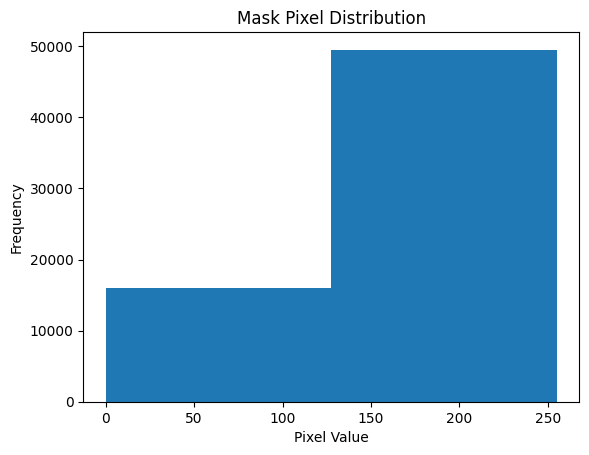

In [9]:
img = cv2.imread(os.path.join(IMAGE_TRAIN_DIR, sample_images[0]))
mask = cv2.imread(os.path.join(MASK_TRAIN_DIR, sample_images[0]), cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)

plt.hist(mask.flatten(), bins=2)
plt.title("Mask Pixel Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


## Data Preprocessing

Preprocessing steps:
 Resize images and masks to fixed dimensions,
 Normalize pixel values,
 Expand mask dimensions for model compatibility.


In [10]:
IMG_SIZE = (128, 128)

def preprocess(image_path, mask_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, IMG_SIZE)
    image = image / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, IMG_SIZE)
    mask = mask / 255.0
    mask = np.expand_dims(mask, axis=-1)

    return image, mask


## Preprocessing Verification


Preprocessed image shape: (128, 128, 3)
Preprocessed mask shape: (128, 128, 1)


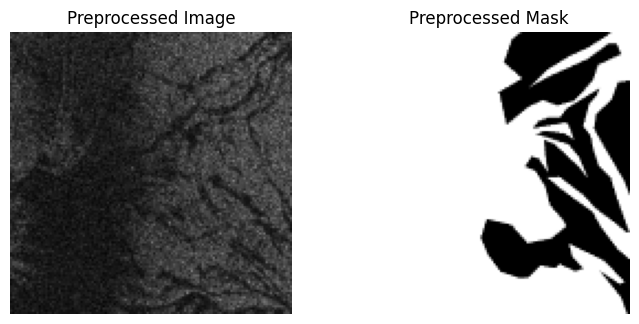

In [11]:
img_p, mask_p = preprocess(
    os.path.join(IMAGE_TRAIN_DIR, sample_images[0]),
    os.path.join(MASK_TRAIN_DIR, sample_images[0])
)

print("Preprocessed image shape:", img_p.shape)
print("Preprocessed mask shape:", mask_p.shape)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_p)
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_p.squeeze(), cmap="gray")
plt.title("Preprocessed Mask")
plt.axis("off")

plt.show()


## Model Architecture

In [13]:
def simple_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)

    u1 = layers.UpSampling2D()(b)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)



In [30]:
def load_dataset(image_dir, mask_dir, img_size=(128,128)):
    images = []
    masks = []

    image_files = sorted(os.listdir(image_dir))

    for img_name in image_files:
        img_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, img_size)
        image = image / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, img_size)
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        images.append(image)
        masks.append(mask)

    return np.array(images), np.array(masks)


In [31]:
X_train, y_train = load_dataset(
    IMAGE_TRAIN_DIR,
    MASK_TRAIN_DIR
)

X_val, y_val = load_dataset(
    IMAGE_VAL_DIR,
    MASK_VAL_DIR
)


In [32]:
print(X_train.shape, y_train.shape)


(6455, 128, 128, 3) (6455, 128, 128, 1)


In [33]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[dice_coefficient]
)


## Model Training

In [34]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=4
)


Epoch 1/5
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 173s 106ms/step - dice_coefficient: 0.6137 - loss: 0.2884 - val_dice_coefficient: 0.6640 - val_loss: 0.2693
Epoch 2/5
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 151s 94ms/step - dice_coefficient: 0.6729 - loss: 0.2458 - val_dice_coefficient: 0.6744 - val_loss: 0.3683
Epoch 3/5
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 148s 92ms/step - dice_coefficient: 0.6875 - loss: 0.2352 - val_dice_coefficient: 0.6946 - val_loss: 0.2620
Epoch 4/5
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 336s 208ms/step - dice_coefficient: 0.6920 - loss: 0.2306 - val_dice_coefficient: 0.6862 - val_loss: 0.2498
Epoch 5/5
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 163s 101ms/step - dice_coefficient: 0.6969 - loss: 0.2269 - val_dice_coefficient: 0.7110 - val_loss: 0.2705


## Prediction and Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


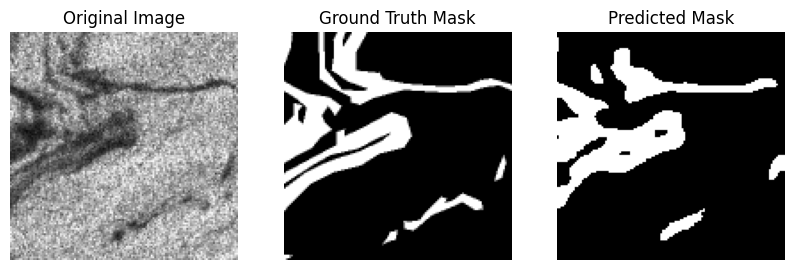

In [35]:
idx = 0
pred = model.predict(X_val[idx:idx+1])

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(X_val[idx])
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(y_val[idx].squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow((pred[0] > 0.5).squeeze(), cmap="gray")
plt.axis("off")

plt.show()
